importing libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

from IPython.display import display

loading data

In [9]:
context = pd.read_csv("gold_match_context.csv")
league = pd.read_csv("gold_match_with_league_standings.csv")
tickets = pd.read_csv("gold_match_tickets.csv")

# merge datasets
df = context.merge(league, on="match_id")
df = df.merge(tickets, on="match_id")

print("Dataset shape:", df.shape)

print("\nFirst rows of merged dataset:")
display(df.head())

print("\nColumn list:")
display(pd.DataFrame(df.columns, columns=["columns"]))

Dataset shape: (71, 72)

First rows of merged dataset:


,match_id,match_date_x,weather_temp_max_c,weather_temp_min_c,weather_temp_mean_c,weather_precipitation_mm,weather_rain_mm,weather_snowfall_cm,weather_windspeed_max_kmh,weather_sunshine_hours,...,league_position_away,tickets_sold_b2c,tickets_sold_b2b,tickets_sold_total,seasonpass_holders,tickets_trib1,tickets_trib2_thuis,tickets_trib2_uit,tickets_trib3,tickets_trib4
0,d256yo3eng04m0fu7b4sl7wno,2022-07-30,25.8,12.9,19.8,0.0,0.0,0.0,10.2,10.3,...,1,488,764,5025,4032,1899,127,0,1427,1572
1,d4mn5ksbxuvnaww4pmommxhqs,2022-08-14,32.2,17.3,25.4,0.0,0.0,0.0,16.9,11.1,...,8,1448,1284,6263,4032,2387,323,0,1982,1571
2,d65hmi7sq03yzr5he1k7ypus4,2022-08-27,21.0,15.9,18.7,0.0,0.0,0.0,13.7,3.9,...,11,439,823,5025,4032,1876,126,0,1453,1570
3,d80mkemezkz16bqh6lbn8tlhw,2022-09-10,18.9,13.6,15.7,8.6,8.6,0.0,23.5,4.1,...,6,782,906,5438,4032,1897,560,0,1411,1570
4,dak40etbhbqsr1nxyt50qcg0k,2022-10-01,17.8,10.9,14.2,9.8,9.8,0.0,34.5,8.5,...,6,1115,970,5844,4032,2163,355,0,1757,1569



Column list:


,columns
0,match_id
1,match_date_x
2,weather_temp_max_c
3,weather_temp_min_c
4,weather_temp_mean_c
...,...
67,tickets_trib1
68,tickets_trib2_thuis
69,tickets_trib2_uit
70,tickets_trib3


cleaning the data, creating new features 

In [10]:
# convert promotion column
df["has_promotion"] = df["has_promotion"].astype(int)

# convert kickoff time
df["kickoff_time_local"] = pd.to_datetime(df["kickoff_time_local"])

# simple time features
df["kickoff_hour"] = df["kickoff_time_local"].dt.hour
df["kickoff_day"] = df["kickoff_time_local"].dt.dayofweek

# remove rows with missing target
df = df.dropna(subset=["tickets_scanned"])

print("Cleaned dataset preview:")
display(df.head())

print("\nBasic statistics:")
display(df.describe())

Cleaned dataset preview:


/var/folders/yz/b26n718j6db76871t423v1jm0000gn/T/ipykernel_30028/3655245631.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["kickoff_time_local"] = pd.to_datetime(df["kickoff_time_local"])


,match_id,match_date_x,weather_temp_max_c,weather_temp_min_c,weather_temp_mean_c,weather_precipitation_mm,weather_rain_mm,weather_snowfall_cm,weather_windspeed_max_kmh,weather_sunshine_hours,...,tickets_sold_b2b,tickets_sold_total,seasonpass_holders,tickets_trib1,tickets_trib2_thuis,tickets_trib2_uit,tickets_trib3,tickets_trib4,kickoff_hour,kickoff_day
0,d256yo3eng04m0fu7b4sl7wno,2022-07-30,25.8,12.9,19.8,0.0,0.0,0.0,10.2,10.3,...,764,5025,4032,1899,127,0,1427,1572,18,2
1,d4mn5ksbxuvnaww4pmommxhqs,2022-08-14,32.2,17.3,25.4,0.0,0.0,0.0,16.9,11.1,...,1284,6263,4032,2387,323,0,1982,1571,18,2
2,d65hmi7sq03yzr5he1k7ypus4,2022-08-27,21.0,15.9,18.7,0.0,0.0,0.0,13.7,3.9,...,823,5025,4032,1876,126,0,1453,1570,18,2
3,d80mkemezkz16bqh6lbn8tlhw,2022-09-10,18.9,13.6,15.7,8.6,8.6,0.0,23.5,4.1,...,906,5438,4032,1897,560,0,1411,1570,20,2
4,dak40etbhbqsr1nxyt50qcg0k,2022-10-01,17.8,10.9,14.2,9.8,9.8,0.0,34.5,8.5,...,970,5844,4032,2163,355,0,1757,1569,16,2



Basic statistics:


,weather_temp_max_c,weather_temp_min_c,weather_temp_mean_c,weather_precipitation_mm,weather_rain_mm,weather_snowfall_cm,weather_windspeed_max_kmh,weather_sunshine_hours,weather_code,weather_temp_deviation,...,tickets_sold_b2b,tickets_sold_total,seasonpass_holders,tickets_trib1,tickets_trib2_thuis,tickets_trib2_uit,tickets_trib3,tickets_trib4,kickoff_hour,kickoff_day
count,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,...,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.0
mean,14.336620,7.136620,10.678873,1.973239,1.923944,0.034507,19.002817,6.185915,36.098592,0.039437,...,1198.295775,6787.563380,4321.887324,2334.535211,562.704225,11.323944,2311.690141,1567.309859,17.971831,2.0
min,2.500000,-3.500000,-0.100000,0.000000,0.000000,0.000000,4.300000,0.000000,2.000000,-6.300000,...,758.000000,4688.000000,4032.000000,1664.000000,56.000000,0.000000,1226.000000,1507.000000,16.000000,2.0
25%,9.300000,2.750000,5.800000,0.000000,0.000000,0.000000,13.350000,3.450000,3.000000,-2.050000,...,920.000000,5903.000000,4235.000000,2057.000000,518.000000,0.000000,1873.000000,1569.000000,16.000000,2.0
50%,13.700000,7.200000,10.500000,0.300000,0.300000,0.000000,18.000000,6.100000,51.000000,0.400000,...,1083.000000,6979.000000,4405.000000,2366.000000,590.000000,0.000000,2412.000000,1570.000000,18.000000,2.0
75%,18.500000,11.600000,14.700000,2.450000,2.100000,0.000000,23.500000,8.600000,55.000000,1.900000,...,1430.000000,7596.000000,4546.000000,2557.000000,787.000000,0.000000,2757.000000,1573.000000,19.000000,2.0
max,32.200000,19.700000,25.400000,15.100000,15.100000,2.100000,38.000000,15.000000,75.000000,6.600000,...,2823.000000,8682.000000,4546.000000,3089.000000,795.000000,198.000000,3245.000000,1577.000000,21.000000,2.0
std,6.820122,6.019023,6.267055,3.253392,3.240347,0.250404,7.351792,3.617904,26.645908,2.982496,...,386.203551,1072.794718,195.556535,362.817460,236.854590,37.185932,575.658048,12.759973,1.539683,0.0


training the model using random forest and removing excessive info

In [12]:
# target variable
y = df["tickets_scanned"]

# remove columns that should not be used in the model
X = df.drop(columns=[
    "match_id",
    "tickets_scanned",
    "kickoff_time_local",
    "match_date_x",          # remove date column
    "promotion_names",
    "promo_tickets_total",
    "pct_free_tickets"
], errors="ignore")

# keep only numeric columns
X = X.select_dtypes(include=["int64", "float64"])

print("Feature dataset:")
display(X.head())

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# train model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# predictions
pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

Feature dataset:


,weather_temp_max_c,weather_temp_min_c,weather_temp_mean_c,weather_precipitation_mm,weather_rain_mm,weather_snowfall_cm,weather_windspeed_max_kmh,weather_sunshine_hours,weather_code,weather_temp_deviation,...,league_position_away,tickets_sold_b2c,tickets_sold_b2b,tickets_sold_total,seasonpass_holders,tickets_trib1,tickets_trib2_thuis,tickets_trib2_uit,tickets_trib3,tickets_trib4
0,25.8,12.9,19.8,0.0,0.0,0.0,10.2,10.3,3,0.9,...,1,488,764,5025,4032,1899,127,0,1427,1572
1,32.2,17.3,25.4,0.0,0.0,0.0,16.9,11.1,3,5.9,...,8,1448,1284,6263,4032,2387,323,0,1982,1571
2,21.0,15.9,18.7,0.0,0.0,0.0,13.7,3.9,3,-0.8,...,11,439,823,5025,4032,1876,126,0,1453,1570
3,18.9,13.6,15.7,8.6,8.6,0.0,23.5,4.1,61,-0.6,...,6,782,906,5438,4032,1897,560,0,1411,1570
4,17.8,10.9,14.2,9.8,9.8,0.0,34.5,8.5,61,1.1,...,6,1115,970,5844,4032,2163,355,0,1757,1569


MAE: 1093.3460000000002
R2: 0.5606664053840649


checking the promotional impact where has_promotion = TRUE is 1 and has_promotion = FALSE is 0

In [13]:
X_temp = X.copy()

# scenario 1: promotion = true
X_temp["has_promotion"] = 1
pred_with_promo = model.predict(X_temp)

# scenario 2: promotion = false
X_temp["has_promotion"] = 0
pred_without_promo = model.predict(X_temp)

# estimated promotion effect
df["promotion_effect"] = pred_with_promo - pred_without_promo

print("Preview of promotion impact:")
display(df[["match_id", "tickets_scanned", "promotion_effect"]].head())

print("\nAverage promotion effect:")
print(df["promotion_effect"].mean())

Preview of promotion impact:


,match_id,tickets_scanned,promotion_effect
0,d256yo3eng04m0fu7b4sl7wno,5565.0,8.850
1,d4mn5ksbxuvnaww4pmommxhqs,7440.0,-16.845
2,d65hmi7sq03yzr5he1k7ypus4,4489.0,3.230
3,d80mkemezkz16bqh6lbn8tlhw,4508.0,1.050
4,dak40etbhbqsr1nxyt50qcg0k,6290.0,-7.115



Average promotion effect:
-56.83204225352114


visualition of data

visualisation of data

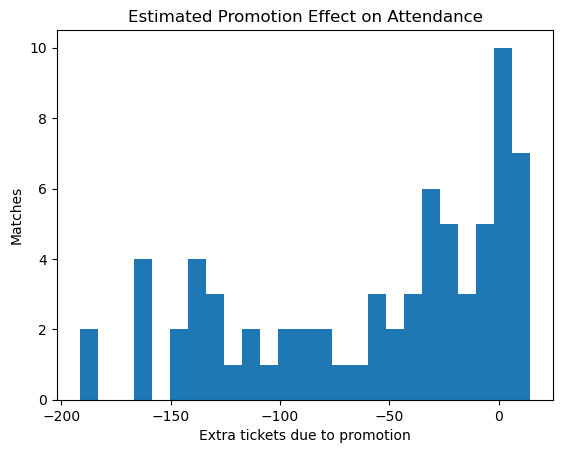


Average attendance comparison:


,has_promotion,tickets_scanned
0,0,7345.333333
1,1,6024.307692


In [14]:
# histogram of estimated promotion effect
plt.hist(df["promotion_effect"], bins=25)
plt.title("Estimated Promotion Effect on Attendance")
plt.xlabel("Extra tickets due to promotion")
plt.ylabel("Matches")
plt.show()

# compare real attendance
comparison = df.groupby("has_promotion")["tickets_scanned"].mean().reset_index()

print("\nAverage attendance comparison:")
display(comparison)

The analysis compared matches with and without promotions.
Matches without promotions had a higher average attendance (7345) compared to matches with promotions (6024).
This suggests that promotions are typically used for matches where lower attendance is expected.
The estimated promotion effect distribution also shows many negative values, indicating that promotions are often applied to lower-demand matches rather than causing increased attendance directly.

<Figure size 800x500 with 0 Axes>

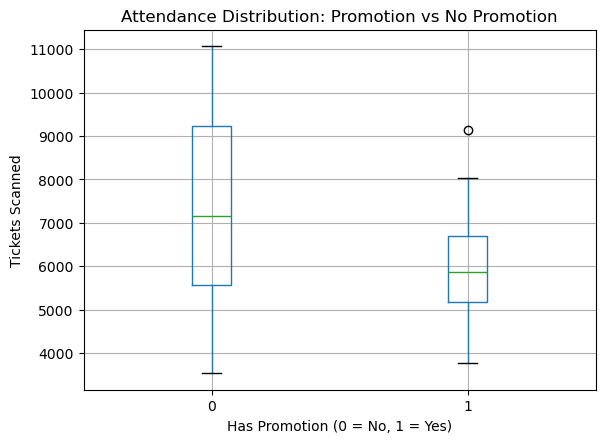

In [15]:
# compare attendance distributions
plt.figure(figsize=(8,5))

df.boxplot(column="tickets_scanned", by="has_promotion")

plt.title("Attendance Distribution: Promotion vs No Promotion")
plt.suptitle("")  # removes automatic pandas title
plt.xlabel("Has Promotion (0 = No, 1 = Yes)")
plt.ylabel("Tickets Scanned")

plt.show()

The boxplot shows that matches without promotions generally have higher attendance compared to matches with promotions. The median attendance for non-promoted matches is approximately 7100 tickets, while promoted matches have a median attendance around 5900 tickets. This suggests that promotions are typically used for matches where lower attendance is expected, rather than being applied to already high-demand matches.